In [ ]:
# Install necessary packages
!pip install torch torchvision
!pip install scikit-image
!pip install numpy
!pip install matplotlib
!pip install tqdm

# Import all required libraries
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, iradon, resize
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import copy

# Set up device (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


In [ ]:
# Generate the ground truth Shepp-Logan phantom
IMG_SIZE = 128
ground_truth = shepp_logan_phantom()
ground_truth = resize(ground_truth, (IMG_SIZE, IMG_SIZE), anti_aliasing=True)

# Convert to a PyTorch tensor and move to the selected device
ground_truth_torch = torch.from_numpy(ground_truth).float().unsqueeze(0).unsqueeze(0).to(device)

In [ ]:
# Define the projection geometry
theta = np.linspace(0., 180., 60, endpoint=False) # 60 angles over 180 degrees

# Apply the Radon transform to get the clean sinogram
sinogram_clean = radon(ground_truth, theta=theta, circle=True)

# Convert to a PyTorch tensor
sinogram_clean_torch = torch.from_numpy(sinogram_clean).float().to(device)

In [ ]:
# Define noise level
NOISE_STD = 0.03 * np.max(sinogram_clean)

# Create and add Gaussian noise
noise = np.random.normal(0, NOISE_STD, sinogram_clean.shape)
sinogram_noisy = sinogram_clean + noise

# Convert to a PyTorch tensor
sinogram_noisy_torch = torch.from_numpy(sinogram_noisy).float().to(device)

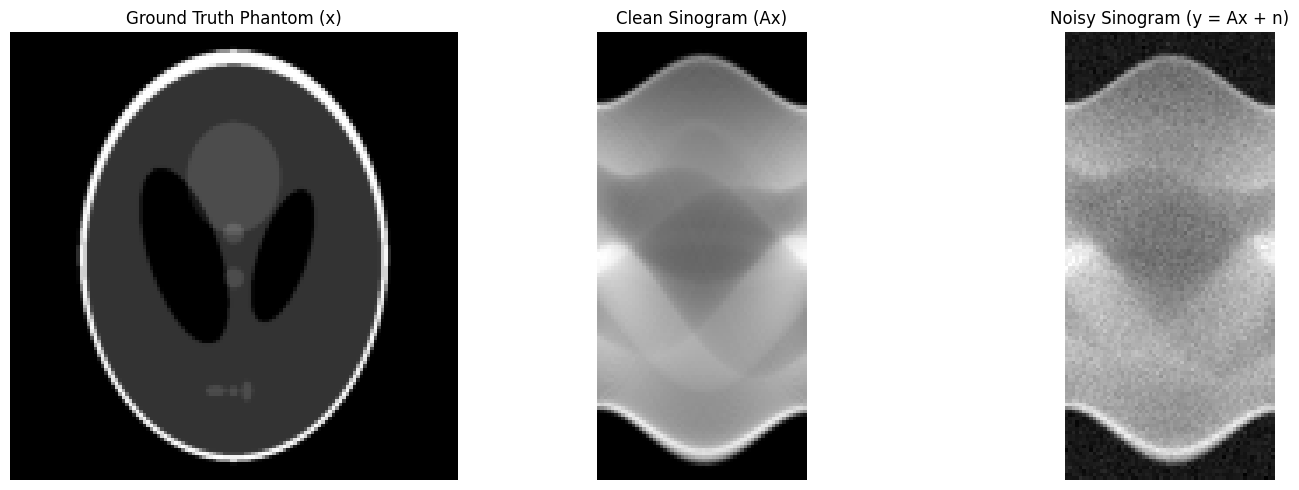

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(ground_truth, cmap='gray')
axes[0].set_title('Ground Truth Phantom (x)')
axes[0].axis('off')

axes[1].imshow(sinogram_clean, cmap='gray')
axes[1].set_title('Clean Sinogram (Ax)')
axes[1].axis('off')

axes[2].imshow(sinogram_noisy, cmap='gray')
axes[2].set_title('Noisy Sinogram (y = Ax + n)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class DIPNetwork(nn.Module):
    def __init__(self, in_channels=32, out_channels=1):
        super(DIPNetwork, self).__init__()
        # Encoder path
        self.enc1 = ConvBlock(in_channels, 64)
        self.enc2 = ConvBlock(64, 128)
        self.enc3 = ConvBlock(128, 256)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(256, 512)

        # Decoder path
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(128, 64)

        # Final output layer
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)
        self.final_activation = nn.Sigmoid()

    def forward(self, z):
        # Encoder
        e1 = self.enc1(z)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        # Bottleneck
        b = self.bottleneck(self.pool(e3))

        # Decoder
        d3 = self.upconv3(b)
        d3 = torch.cat((d3, e3), dim=1)
        d3 = self.dec3(d3)

        d2 = self.upconv2(d3)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.dec2(d2)

        d1 = self.upconv1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.dec1(d1)

        # Output
        out = self.final_conv(d1)
        return self.final_activation(out)

In [ ]:
def forward_operator_A(image_tensor, angles):
    """Applies the Radon transform (A)."""
    # Move tensor to CPU and convert to NumPy
    image_numpy = image_tensor.squeeze().cpu().detach().numpy()
    # Apply Radon transform
    sinogram = radon(image_numpy, theta=angles, circle=True)
    # Convert back to PyTorch tensor and move to device
    return torch.from_numpy(sinogram).float().to(device)

def adjoint_operator_AT(sinogram_tensor, angles):
    """Applies the unfiltered back-projection (A^T)."""
    # Move tensor to CPU and convert to NumPy
    sinogram_numpy = sinogram_tensor.cpu().detach().numpy()
    # Apply inverse Radon transform without filtering
    reconstruction = iradon(sinogram_numpy, theta=angles, circle=True, filter_name=None)
    # Resize to match the original image size
    reconstruction = resize(reconstruction, (IMG_SIZE, IMG_SIZE), anti_aliasing=True)
    # Convert back to PyTorch tensor and move to device
    return torch.from_numpy(reconstruction).float().unsqueeze(0).unsqueeze(0).to(device)

In [ ]:
def solve_x_update(y, z, u, rho, angles, n_cg_iter=10):
    """Solves the x-update subproblem using Conjugate Gradient."""
    b = adjoint_operator_AT(y, angles) + rho * (z - u)
    x = z.clone() # Start with a good initial guess
    r = b - (adjoint_operator_AT(forward_operator_A(x, angles), angles) + rho * x)
    p = r.clone()
    rs_old = torch.sum(r * r)

    for i in range(n_cg_iter):
        Ap = adjoint_operator_AT(forward_operator_A(p, angles), angles) + rho * p
        alpha = rs_old / torch.sum(p * Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        rs_new = torch.sum(r * r)
        if torch.sqrt(rs_new) < 1e-5:
            break
        p = r + (rs_new / rs_old) * p
        rs_old = rs_new
    return x

In [ ]:
def mcdip_admm_reconstruction(sinogram_noisy, angles, ground_truth,
                              n_admm_iter=30, n_dip_iter=100,
                              rho=0.1, N_ensemble=5, lr=1e-3):
    """Performs reconstruction using the MCDIP-ADMM algorithm."""

    # Initialize variables
    # Start with a simple FBP reconstruction as initial guess for x and z
    fbp_init = iradon(sinogram_noisy.cpu().numpy(), theta=angles, circle=True)
    fbp_init = resize(fbp_init, (IMG_SIZE, IMG_SIZE), anti_aliasing=True)
    x = torch.from_numpy(fbp_init).float().unsqueeze(0).unsqueeze(0).to(device)
    z = x.clone()
    u = torch.zeros_like(x).to(device)

    # Initialize the ensemble of DIP networks and their inputs/optimizers
    dip_ensemble = [DIPNetwork().to(device) for _ in range(N_ensemble)]
    latent_codes = [torch.randn(1, 32, IMG_SIZE, IMG_SIZE, device=device) for _ in range(N_ensemble)]
    optimizers = [optim.Adam(net.parameters(), lr=lr) for net in dip_ensemble]

    # Store metrics for plotting
    psnr_history = []
    ssim_history = []

    # Main ADMM loop
    for k in tqdm(range(n_admm_iter), desc="ADMM Iterations"):
        # 1. x-update
        x = solve_x_update(sinogram_noisy, z, u, rho, angles)

        # 2. z-update (MCDIP prior)
        dip_outputs = []
        target = x + u

        for i in range(N_ensemble):
            net = dip_ensemble[i]
            optimizer = optimizers[i]
            c_i = latent_codes[i]

            # Inner loop to optimize each DIP
            for _ in range(n_dip_iter):
                optimizer.zero_grad()
                output = net(c_i)
                loss = nn.MSELoss()(output, target)
                loss.backward()
                optimizer.step()

            dip_outputs.append(net(c_i).detach())

        # Average the outputs of the ensemble
        z = torch.mean(torch.stack(dip_outputs), dim=0)

        # 3. u-update
        u = u + x - z

        # Calculate and store metrics
        current_x_numpy = x.squeeze().cpu().detach().numpy()
        current_psnr = psnr(ground_truth, current_x_numpy, data_range=1.0)
        current_ssim = ssim(ground_truth, current_x_numpy, data_range=1.0)
        psnr_history.append(current_psnr)
        ssim_history.append(current_ssim)

        if (k + 1) % 5 == 0:
            print(f"Iter {k+1}/{n_admm_iter} - PSNR: {current_psnr:.2f}, SSIM: {current_ssim:.4f}")

    return x.squeeze().cpu().detach().numpy(), psnr_history, ssim_history

In [ ]:
reconstructed_image, psnr_history, ssim_history = mcdip_admm_reconstruction(sinogram_noisy_torch, theta, ground_truth)

ADMM Iterations:   0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


Iter 5/30 - PSNR: 21.81, SSIM: 0.3296
Iter 10/30 - PSNR: 21.29, SSIM: 0.3445
Iter 15/30 - PSNR: 21.00, SSIM: 0.3504
Iter 20/30 - PSNR: 20.78, SSIM: 0.3551
Iter 25/30 - PSNR: 20.63, SSIM: 0.3601
Iter 30/30 - PSNR: 20.46, SSIM: 0.3638


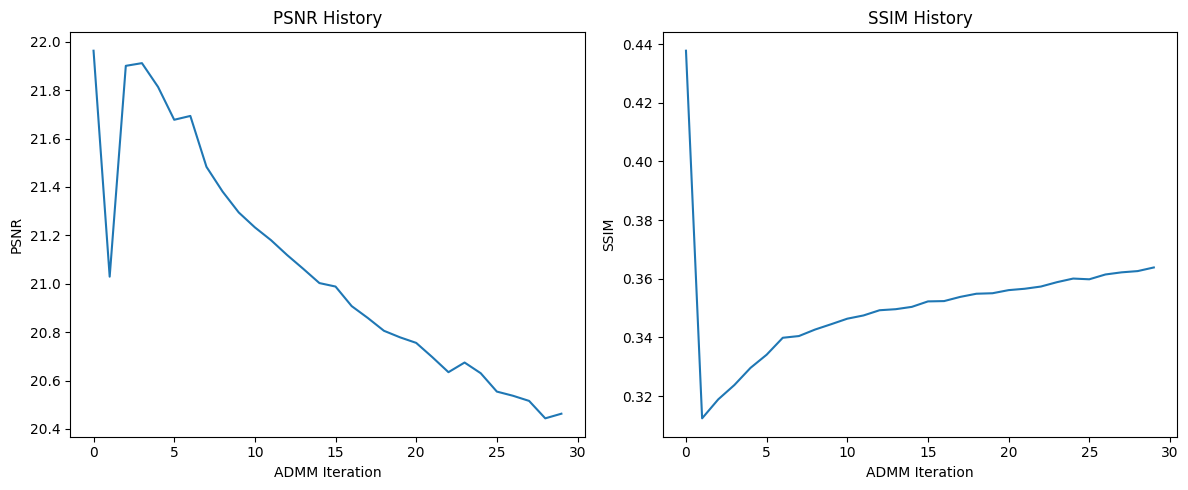

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(psnr_history)
plt.xlabel("ADMM Iteration")
plt.ylabel("PSNR")
plt.title("PSNR History")

plt.subplot(1, 2, 2)
plt.plot(ssim_history)
plt.xlabel("ADMM Iteration")
plt.ylabel("SSIM")
plt.title("SSIM History")

plt.tight_layout()
plt.show()

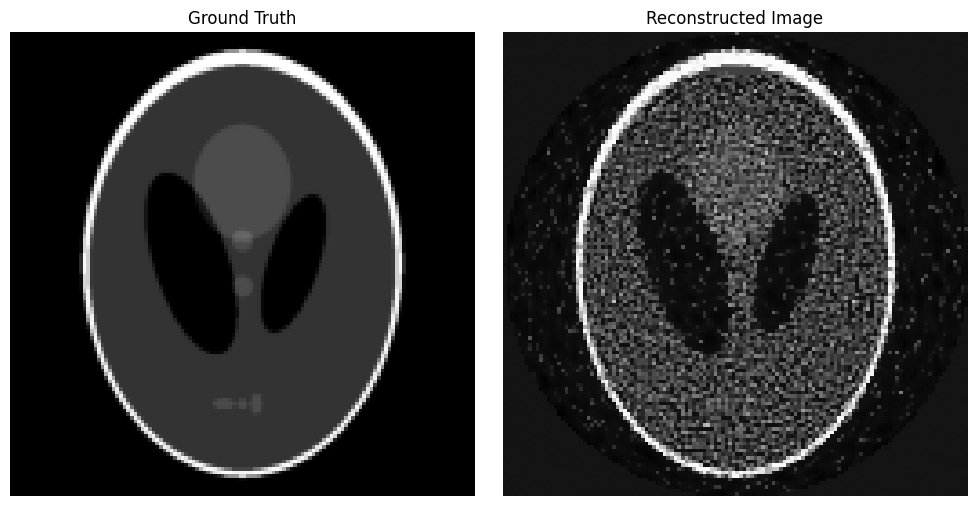

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(ground_truth, cmap='gray')
plt.title('Ground Truth')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_image, cmap='gray')
plt.title('Reconstructed Image')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def fbp_reconstruction(sinogram_noisy, angles):
    """Performs FBP reconstruction."""
    recon_fbp = iradon(sinogram_noisy.cpu().numpy(), theta=angles, circle=True, filter_name='ramp')
    recon_fbp = resize(recon_fbp, (IMG_SIZE, IMG_SIZE), anti_aliasing=True)
    return recon_fbp

In [ ]:
# --- Execute Reconstructions ---

# 1. FBP Baseline
print("Running Filtered Back-Projection (FBP)...")
recon_fbp = fbp_reconstruction(sinogram_noisy_torch, theta)
psnr_fbp = psnr(ground_truth, recon_fbp, data_range=1.0)
ssim_fbp = ssim(ground_truth, recon_fbp, data_range=1.0)
print(f"FBP Result - PSNR: {psnr_fbp:.2f}, SSIM: {ssim_fbp:.4f}\n")

# 2. ADMM-DIP (N=1) Baseline
print("Running ADMM-DIP (N=1)...")
recon_admm_dip, psnr_hist_dip, ssim_hist_dip = mcdip_admm_reconstruction(
    sinogram_noisy_torch, theta, ground_truth,
    n_admm_iter=30, n_dip_iter=100, rho=0.1, N_ensemble=1, lr=1e-3
)
psnr_admm_dip = psnr(ground_truth, recon_admm_dip, data_range=1.0)
ssim_admm_dip = ssim(ground_truth, recon_admm_dip, data_range=1.0)
print(f"ADMM-DIP (N=1) Result - PSNR: {psnr_admm_dip:.2f}, SSIM: {ssim_admm_dip:.4f}\n")

# 3. MCDIP-ADMM (N=5) Proposed Method
print("Running MCDIP-ADMM (N=5)...")
recon_mcdip_admm, psnr_hist_mcdip, ssim_hist_mcdip = mcdip_admm_reconstruction(
    sinogram_noisy_torch, theta, ground_truth,
    n_admm_iter=30, n_dip_iter=100, rho=0.1, N_ensemble=5, lr=1e-3
)
psnr_mcdip_admm = psnr(ground_truth, recon_mcdip_admm, data_range=1.0)
ssim_mcdip_admm = ssim(ground_truth, recon_mcdip_admm, data_range=1.0)
print(f"MCDIP-ADMM (N=5) Result - PSNR: {psnr_mcdip_admm:.2f}, SSIM: {ssim_mcdip_admm:.4f}\n")

Running Filtered Back-Projection (FBP)...
FBP Result - PSNR: 22.15, SSIM: 0.4467

Running ADMM-DIP (N=1)...


ADMM Iterations:   0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


Iter 5/30 - PSNR: 21.83, SSIM: 0.3311
Iter 10/30 - PSNR: 21.26, SSIM: 0.3353
Iter 15/30 - PSNR: 21.00, SSIM: 0.3514
Iter 20/30 - PSNR: 20.76, SSIM: 0.3547
Iter 25/30 - PSNR: 20.61, SSIM: 0.3599
Iter 30/30 - PSNR: 20.47, SSIM: 0.3642
ADMM-DIP (N=1) Result - PSNR: 20.47, SSIM: 0.3642

Running MCDIP-ADMM (N=5)...


ADMM Iterations:   0%|          | 0/30 [00:00<?, ?it/s]

Iter 5/30 - PSNR: 21.81, SSIM: 0.3283
Iter 10/30 - PSNR: 21.32, SSIM: 0.3432
Iter 15/30 - PSNR: 21.03, SSIM: 0.3493
Iter 20/30 - PSNR: 20.79, SSIM: 0.3533
Iter 25/30 - PSNR: 20.61, SSIM: 0.3579
Iter 30/30 - PSNR: 20.42, SSIM: 0.3618
MCDIP-ADMM (N=5) Result - PSNR: 20.42, SSIM: 0.3618



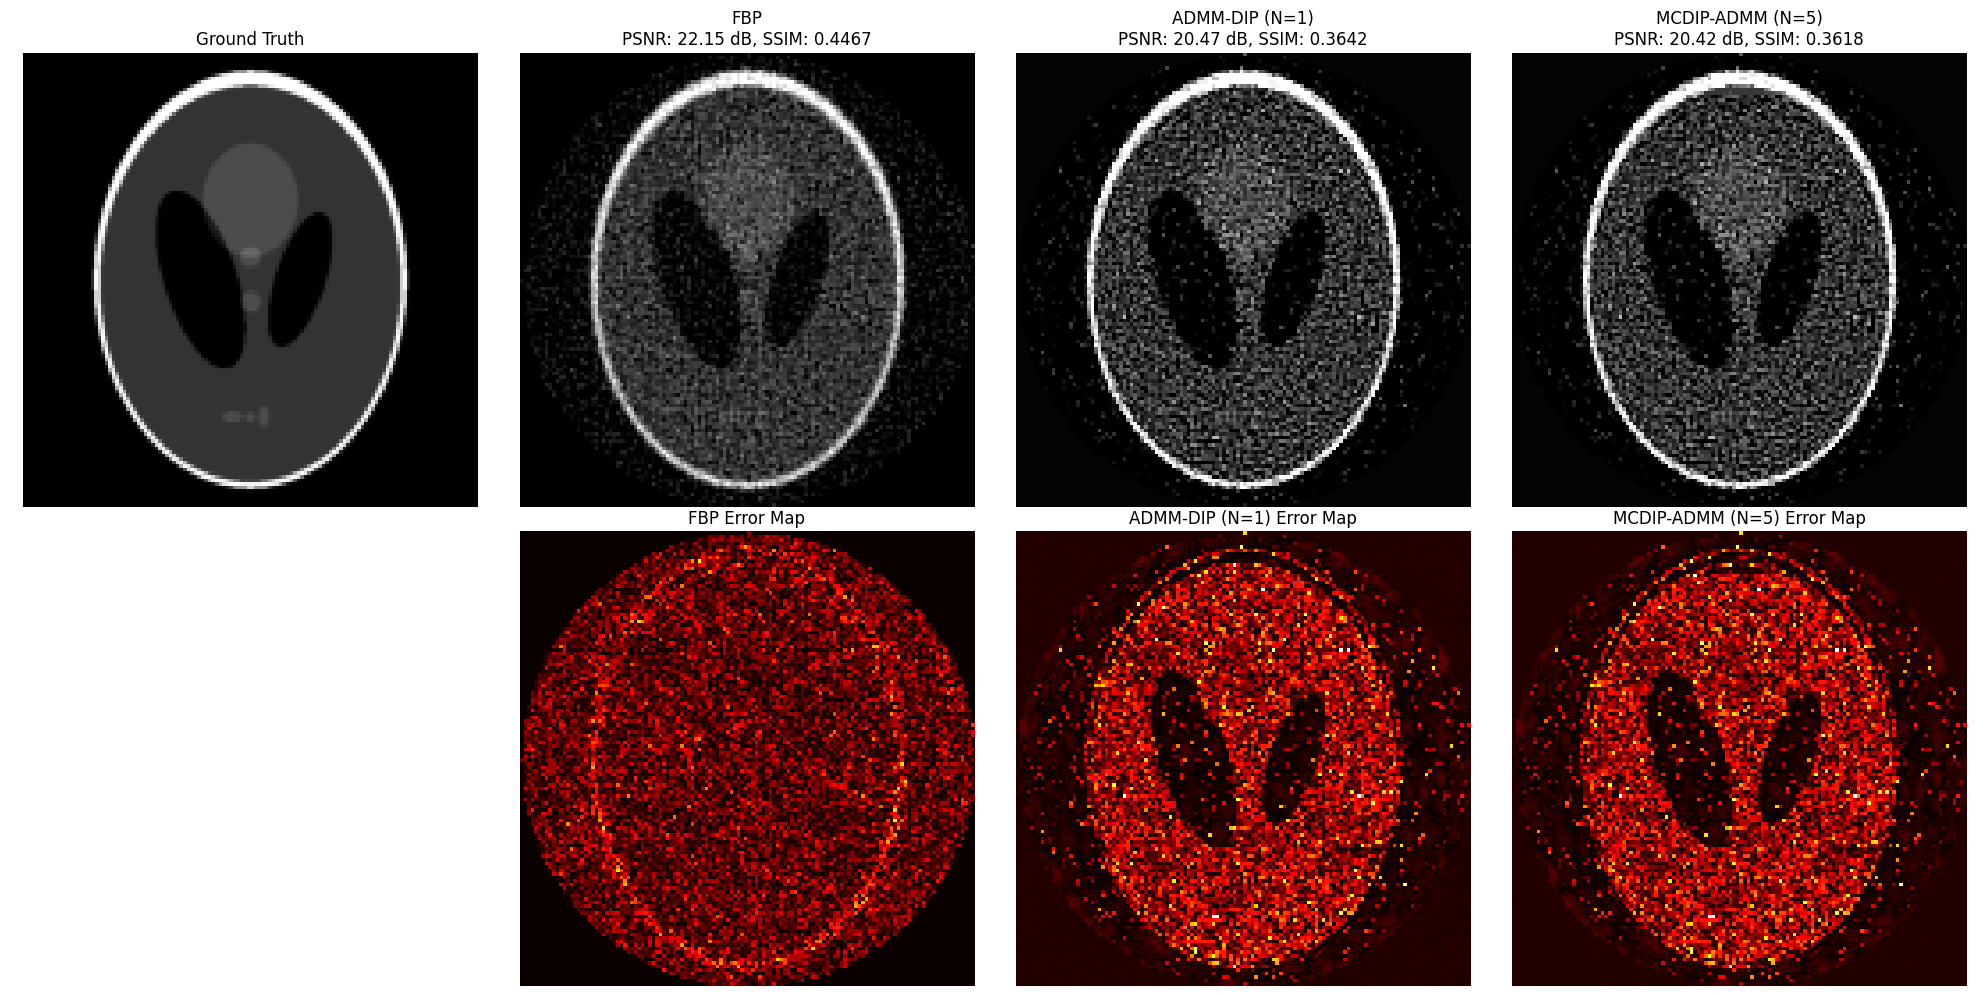

In [ ]:
# --- Visualize Results ---
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Plot reconstructions
axes[0, 0].imshow(ground_truth, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title(f'Ground Truth')
axes[0, 0].axis('off')

axes[0, 1].imshow(recon_fbp, cmap='gray', vmin=0, vmax=1)
axes[0, 1].set_title(f'FBP\nPSNR: {psnr_fbp:.2f} dB, SSIM: {ssim_fbp:.4f}')
axes[0, 1].axis('off')

axes[0, 2].imshow(recon_admm_dip, cmap='gray', vmin=0, vmax=1)
axes[0, 2].set_title(f'ADMM-DIP (N=1)\nPSNR: {psnr_admm_dip:.2f} dB, SSIM: {ssim_admm_dip:.4f}')
axes[0, 2].axis('off')

axes[0, 3].imshow(recon_mcdip_admm, cmap='gray', vmin=0, vmax=1)
axes[0, 3].set_title(f'MCDIP-ADMM (N=5)\nPSNR: {psnr_mcdip_admm:.2f} dB, SSIM: {ssim_mcdip_admm:.4f}')
axes[0, 3].axis('off')

# Plot error maps
error_fbp = np.abs(ground_truth - recon_fbp)
axes[1, 1].imshow(error_fbp, cmap='hot', vmin=0, vmax=0.5)
axes[1, 1].set_title('FBP Error Map')
axes[1, 1].axis('off')

error_admm_dip = np.abs(ground_truth - recon_admm_dip)
axes[1, 2].imshow(error_admm_dip, cmap='hot', vmin=0, vmax=0.5)
axes[1, 2].set_title('ADMM-DIP (N=1) Error Map')
axes[1, 2].axis('off')

error_mcdip_admm = np.abs(ground_truth - recon_mcdip_admm)
axes[1, 3].imshow(error_mcdip_admm, cmap='hot', vmin=0, vmax=0.5)
axes[1, 3].set_title('MCDIP-ADMM (N=5) Error Map')
axes[1, 3].axis('off')

# Hide the empty subplot for ground truth error
axes[1, 0].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

data = {'Method': ['FBP', 'ADMM-DIP (N=1)', 'MCDIP-ADMM (N=5)'],
        'PSNR (dB)': [psnr_fbp, psnr_admm_dip, psnr_mcdip_admm],
        'SSIM': [ssim_fbp, ssim_admm_dip, ssim_mcdip_admm]}

df_results = pd.DataFrame(data)

# Format the values for better readability
df_results['PSNR (dB)'] = df_results['PSNR (dB)'].map('{:.2f}'.format)
df_results['SSIM'] = df_results['SSIM'].map('{:.4f}'.format)

display(df_results)

,Method,PSNR (dB),SSIM
0,FBP,22.15,0.4467
1,ADMM-DIP (N=1),20.47,0.3642
2,MCDIP-ADMM (N=5),20.42,0.3618


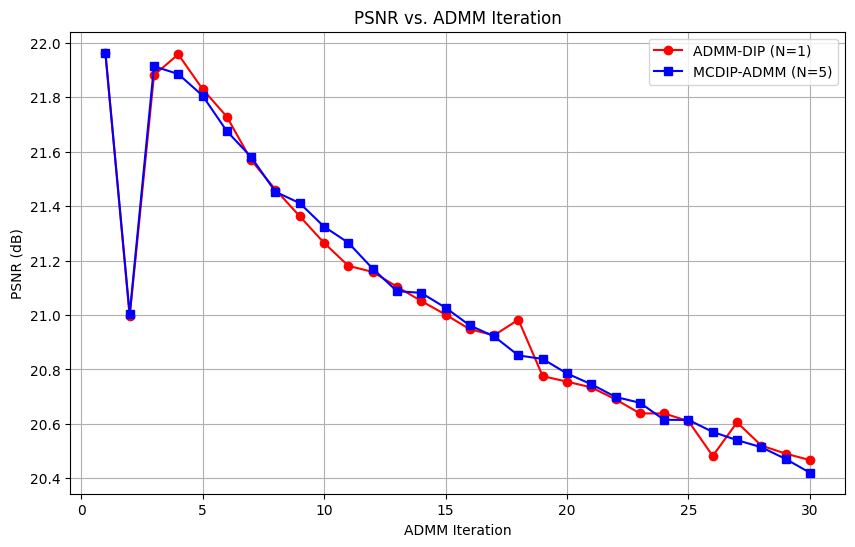

In [ ]:
# --- Plot Convergence ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, 31), psnr_hist_dip, 'r-o', label='ADMM-DIP (N=1)')
plt.plot(range(1, 31), psnr_hist_mcdip, 'b-s', label='MCDIP-ADMM (N=5)')
plt.title('PSNR vs. ADMM Iteration')
plt.xlabel('ADMM Iteration')
plt.ylabel('PSNR (dB)')
plt.grid(True)
plt.legend()
plt.show()